In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import os

from utils.utils_clf import *
from clf_models import load_model

In [3]:
base_dataset = torchvision.datasets.STL10(root='/home/sunaybhat/data', split='train', download=(not os.path.exists(os.path.join('/home/sunaybhat/data', 'stl10_binary'))),transform=transforms.ToTensor())

# model = load_model('ResNet18_HLB', num_classes=10, img_size=96)

# model.linear

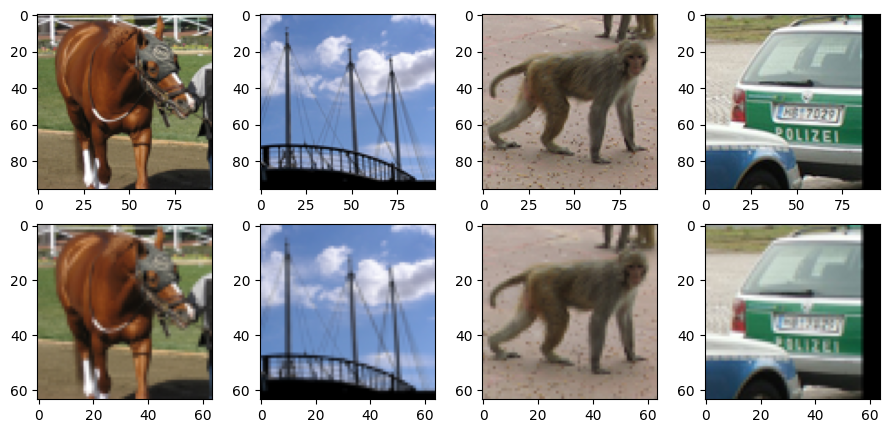

In [14]:
# Sample 4 images from the dataset
size = 64
idxs = np.random.choice(len(base_dataset), 4, replace=False)

images = [base_dataset[idx][0] for idx in idxs]
images_resized = [torchvision.transforms.Resize((size,size))(img) for img in images]

fig,axs = plt.subplots(2,4,figsize=(11,5))

# PLot the original image on top row amd resized image on bottom row
for i in range(4):
    axs[0,i].imshow(images[i].permute(1,2,0))
    axs[1,i].imshow(images_resized[i].permute(1,2,0))

In [14]:
base_loader = data.DataLoader(base_dataset, batch_size=500, shuffle=False, num_workers=4)

train_data = PoisonedDataset(base_loader, poisoned = False, transform=transforms.Compose([transforms.ToTensor()]))

train_loader = torch.utils.data.DataLoader(train_data, batch_size=500, shuffle=True,num_workers=4)

In [15]:
images, labels ,_,_ = next(iter(train_loader))

In [16]:
images.shape

torch.Size([500, 3, 96, 96])